### Quantum Adder: Step-by-Step Guide

- https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CDKMRippleCarryAdder

In [2]:
%matplotlib inline

import sys
sys.path.append("../src")

from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit import transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.circuit.library import CDKMRippleCarryAdder

This guide describes the logic behind a Cuccaro-stype quantum ripple-carry adder as used in Qiskit's CDKMRRippleCarryAdder that performs $|a \rangle|b \rangle|0 \rangle \rightarrow |a \rangle|(a+b) \rangle|c \rangle$

The algorithm consists of two parts, namely 1) the MAJ block (carry forward) and 2) the UMA block (sum and uncompute).

### MAJ block

Applies the majority function, i.e., sets $c_i$ to 1 if any two  values of $a_i, b_i$ or $c_i$ are 1.

For example $c_i = Majority(1, 1, 0) = 1$

$\mathrm{CNOT}(c_i \rightarrow b_i)$  
$\mathrm{CNOT}(c_i \rightarrow a_i)$  
$\mathrm{Toffoli}(a_i, b_i \rightarrow c_i)$

In [47]:
def MAJ():
    a_reg = QuantumRegister(1, 'a') 
    b_reg = QuantumRegister(1, 'b') 
    c_reg = QuantumRegister(1, 'c')
    
    qc = QuantumCircuit(a_reg, b_reg, c_reg)

    qc.cx(c_reg, b_reg)
    qc.cx(c_reg, a_reg)
    qc.ccx(a_reg, b_reg, c_reg)
    
    return qc.to_gate(label="MAJ")

### UMA block

$\mathrm{Toffoli}(a_i, b_i \rightarrow c_i)$ uncomputes $\rangle|c \rangle$  
$\mathrm{CNOT}(c_i \rightarrow a_i)$ uncomputes $\rangle|a \rangle$  
$\mathrm{CNOT}(a_i \rightarrow b_i)$ writes sum of $|(a+b) \rangle$ into the $|b \rangle$ register

Let's start with the following example. We have two numbers $|a \rangle=3$ and $|b \rangle=5$ which we want to add, represented with 3 qubits each. Therefore, we have $a = a_0, a_1, a_2$ and $b = b_0, b_1, b_2$. To add these numbers we need one additional carry bit $|c \rangle$.

First, we apply the MAJ block for each qubit in a and b. At the end write the ancilla into $c_{out}$. Then apply the UMA block for each qubit in a and b to uncompute a and c and write the sum of a+b into the b register.

In [63]:
def UMA():
    a_reg = QuantumRegister(1, 'a') 
    b_reg = QuantumRegister(1, 'b') 
    c_reg = QuantumRegister(1, 'c')
    
    qc = QuantumCircuit(a_reg, b_reg, c_reg)

    qc.ccx(a_reg, b_reg, c_reg)
    qc.cx(c_reg, a_reg)
    qc.cx(a_reg, b_reg)
    
    return qc.to_gate(label="UMA")

### Constructing the circuit

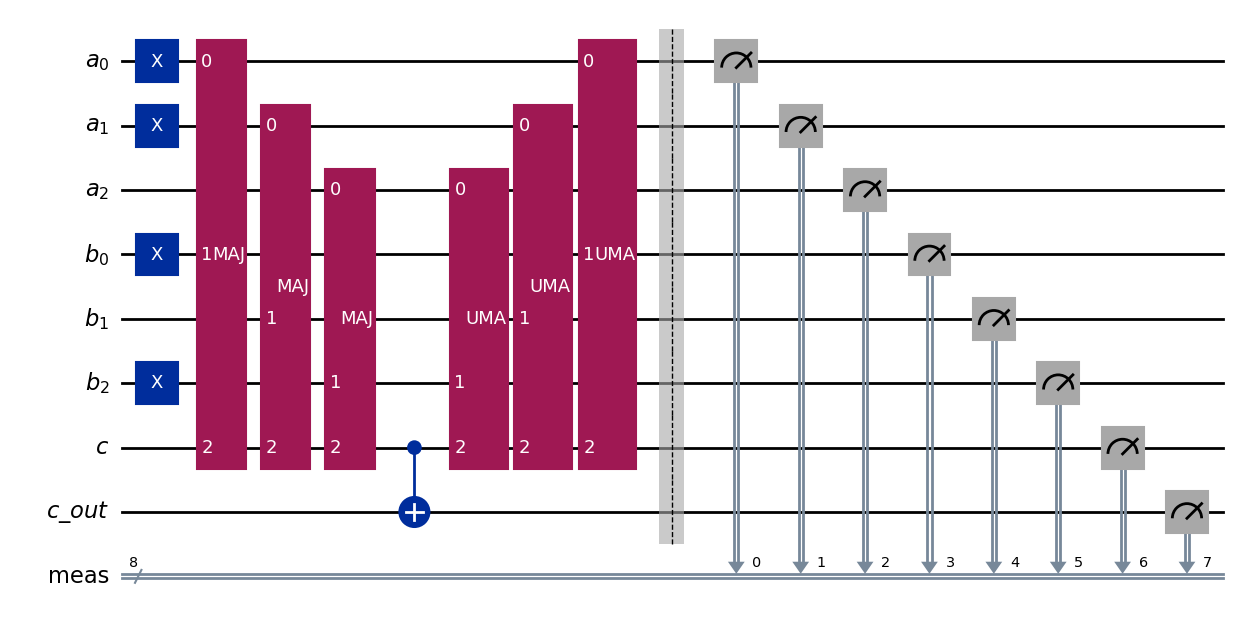

In [85]:
n = 3

a_val = 3
b_val = 5

a_reg = QuantumRegister(n, 'a') 
b_reg = QuantumRegister(n, 'b') 
c_reg = QuantumRegister(1, 'c')
c_out_reg = QuantumRegister(1, 'c_out')

qc = QuantumCircuit(a_reg, b_reg, c_reg, c_out_reg)

# prepare registers
for i in range(n):
    if (a_val >> i) & 1:
        qc.x(a_reg[i])
    if (b_val >> i) & 1:
        qc.x(b_reg[i])

# Apply MAJ for every bit in a and b
for i in range(n):
    qc.append(MAJ(), [a_reg[i], b_reg[i], c_reg[0]])

# Write final ancilla value into c_out
qc.cx(c_reg[0], c_out_reg[0])

# Apply UMA for every bit in a and b
for i in reversed(range(n)):
    qc.append(UMA(), [a_reg[i], b_reg[i], c_reg[0]])

qc_measure = qc.copy()
qc_measure.measure_all()

qc_measure.draw('mpl')

In [69]:
sim = AerSimulator(method="matrix_product_state")

tqc = transpile(qc_measure, sim)

nbr_shots = 2**12
result = sim.run(tqc, shots=nbr_shots).result()
counts = result.get_counts()

counts # c_out, c, b0, b1, b2, a0, a1, a2

{'10000011': 4096}

In [89]:
bitstring = list(counts.keys())[0]

a = int(bitstring[-3:], 2)        # a2, a1, a0
b = int(bitstring[-6:-3], 2)      # b2, b1, b0
c = int(bitstring[-7], 2)         # c
c_out = int(bitstring[-8], 2)     # c_out


# combine b with c_out → b2 b1 b0 c_out
b_combined = int(bitstring[-8] + bitstring[-6:-3], 2) # c_out, b2, b1, b0

print("a =", a)
print("b =", b)
print("c =", c)
print("c_out =", c_out)
print("b_combined =", b_combined)

# expected result is a + b = 3 + 5 = 8

a = 3
b = 0
c = 0
c_out = 1
b_combined = 8


### How it works

To understand how and why it works, let's go through all possible combinations for $a=\{0, 1\}$, $b=\{0, 1\}$ and $c=\{0, 1\}$.

### We start with the scnario where $c_i=0$

MAJ block

$\mathrm{CNOT}(c_i \rightarrow b_i)$  
$\mathrm{CNOT}(c_i \rightarrow a_i)$  
$\mathrm{Toffoli}(a_i, b_i \rightarrow c_i)$

and $c_i=0$, therefore we only need to apply the Toffoli gate in that scenario, as the first two CNOT gates would require c to be in the 1 state.

Values for a and b between 0 and 15 can be represented by 3 qubits each. Therefore, we see the following 4 combinations of a and b read from right (LSB) to left (MSB) at the starting point.

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

If we apply the Toffoli gate, the overflow bit c changes as follows, and the carry bit only flips from $c_i=0$ to $c_i=1$ in the scenario where both $a_i$ and $b_i$ are 1.

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

At the end of the MAJ block only in the scenario where a and b added led to $c_i=1$, the $c_{out}$ qubit is flipped to 1.

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

Next the UMA block to uncompute c and a again and write the sum into the b register

$\mathrm{Toffoli}(a_i, b_i \rightarrow c_i)$  
$\mathrm{CNOT}(c_i \rightarrow a_i)$  
$\mathrm{CNOT}(a_i \rightarrow b_i)$

So the Toffoli gate uncomputes the ancilla again and sets it to zero.  

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

The first CNOT has no effect as c is set back to zero.  
The second CNOT writes $(a+b)$ into the b register by flipping the b register if the a register is 1.  
At that stage $|a \rangle=$ is back to $|a \rangle=$, $|b \rangle = |(a+b) \rangle$ and $|c \rangle=0$.

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

Which makes sense as read from right to left a + b in binary:
1) 0 + 0 = 00 which is $c_{out}, b_i$
2) 1 + 0 = 01
3) 0 + 1 = 01
4) 1 + 1 = 11

### We continue with the scnario where $c_i=1$

MAJ block

$\mathrm{CNOT}(c_i \rightarrow b_i)$  
$\mathrm{CNOT}(c_i \rightarrow a_i)$  
$\mathrm{Toffoli}(a_i, b_i \rightarrow c_i)$

and $c_i=1$, therefore in addition to the Toffoli gate we now also need to apply the both CNOT gates, as c is in state 1.

Values for a and b between 0 and 15 can be represented by 3 qubits each. Therefore, we see the following 4 combinations of a and b at the starting point.

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

First we eapply the two CNOT gates which flip both a and b as c is 1 in each of these scenarios

$\mathrm{CNOT}(c_i \rightarrow b_i)$  
$\mathrm{CNOT}(c_i \rightarrow a_i)$  

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

Next we apply the Toffoli gate and switch the ancilla to 0 if both a and b are 1, which happens only in one scenario

$\mathrm{Toffoli}(a_i, b_i \rightarrow c_i)$

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

At the end of the MAJ block we again check the scenarios where the ancilla is 1 (overflow qubuit) and flip the $c_{out}$ qubit to 1.  
This happens only in the scenario where a and b where zero and c was one at the start. All other scenarios created an overflow bit.

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

Next we again apply the UMA block to uncompute c and a again and write the sum into the b register

$\mathrm{Toffoli}(a_i, b_i \rightarrow c_i)$  
$\mathrm{CNOT}(c_i \rightarrow a_i)$  
$\mathrm{CNOT}(a_i \rightarrow b_i)$

We uncompute c and a with the Toffoli and CNOT again

$\mathrm{Toffoli}(a_i, b_i \rightarrow c_i)$  
$\mathrm{CNOT}(c_i \rightarrow a_i)$  

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

And in last step write the sum of $a+b$ into the b register.

$\mathrm{CNOT}(a_i \rightarrow b_i)$

<table style="border-collapse: collapse; margin-top: 10px;">
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$a_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$b_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_i$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
  <tr>
    <td style="border: 1px solid black; padding: 6px;">$c_{out}$</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">1</td>
    <td style="border: 1px solid black; padding: 6px;">0</td>
  </tr>
</table>

We again verify the results from right to left in binary, this time where $c_i=1$. Note that $b_i$ and $c_{cout}$ have to be combined / read together.  
Note again that $a_i$ and $c_i$ are back in their initial states.
1) 0 + 0 + 1 = 01 which stands for $c_{out}, b_i$
2) 1 + 0 + 1 = 10
3) 0 + 1 + 1 = 10
4) 1 + 1 + 1 = 11